# Credit Card Customer Churn Prediction

## 1. Import Libraries

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

## 2. Load Dataset

In [168]:
df = pd.read_csv("BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3. Data Understanding

In [169]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


The dataset contains 10,127 observations and 23 variables. It includes a mix of categorical and numerical features. No missing values were found in the dataset, indicating good data quality.

## 4. Data Cleaning

In [170]:
df = df.drop([
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
], axis=1)

##### Convert Target Variable

In [171]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

##### Check Missing Values

In [172]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

## 5. Exploratory Data Analysis (EDA)

##### 1. Churn Distribution

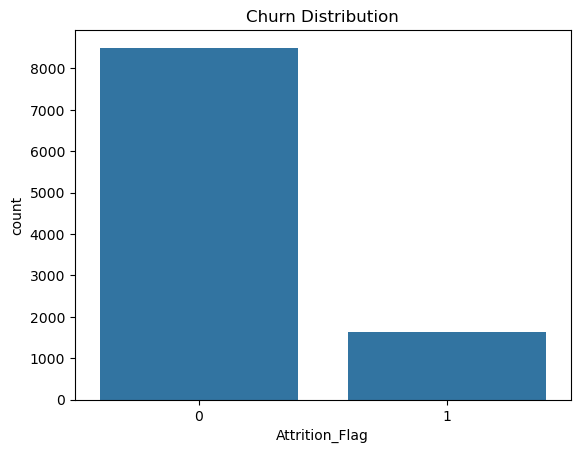

In [173]:
sns.countplot(x='Attrition_Flag', data=df)
plt.title("Churn Distribution")
plt.savefig("Churn_Distribution", bbox_inches='tight')
plt.show()

Note: 0 represents existing customers and 1 represents customers who have churned.

##### Age vs Churn

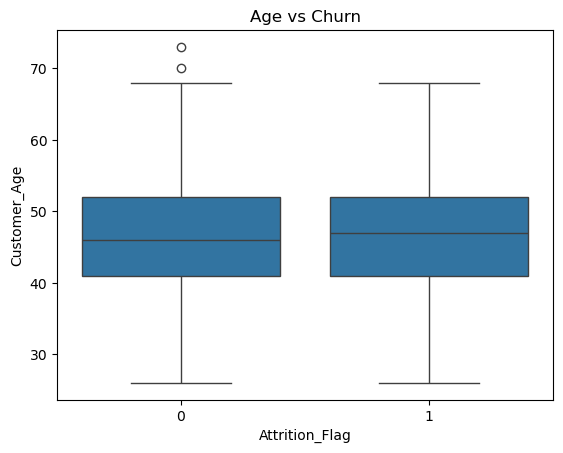

In [174]:
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=df)
plt.title("Age vs Churn")
plt.savefig("Age_vs_Churn", bbox_inches='tight')
plt.show()

##### Credit Limit vs Churn

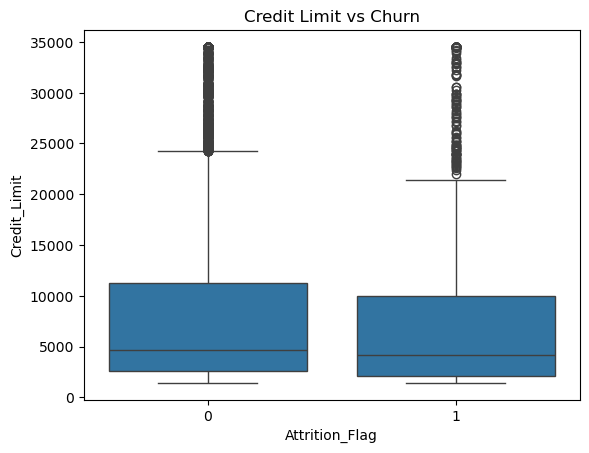

In [175]:
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=df)
plt.title("Credit Limit vs Churn")
plt.savefig("Credit_Limit_vs_Chur", bbox_inches='tight')
plt.show()

##### Transactions vs Churn

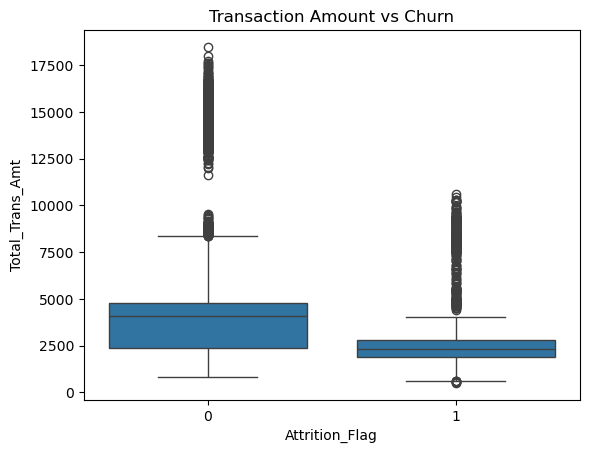

In [176]:
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=df)
plt.title("Transaction Amount vs Churn")
plt.savefig("Transaction_Amount_vs_Churn", bbox_inches='tight')
plt.show()

##### Gender vs Churn

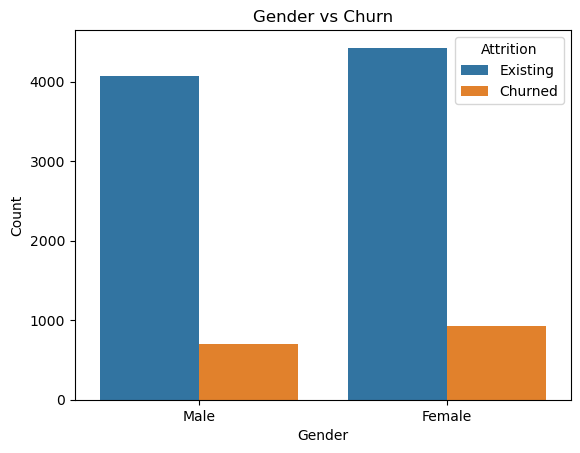

In [177]:
df['Gender_Label'] = df['Gender'].map({'M': 'Male', 'F': 'Female'})

sns.countplot(x='Gender_Label', hue='Attrition_Flag', data=df)
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Attrition", labels=["Existing", "Churned"])
plt.savefig("Gender_vs_Churn.png", bbox_inches='tight')
plt.show()

The chart shows the distribution of customers by gender and churn status. Both male and female customers follow a similar pattern, indicating that gender does not significantly impact churn behavior.

## 6. Feature Engineering

##### Encode Categorical Variables

In [178]:
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## 7. Modeling

##### Split Data

In [179]:
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

##### Logistic Regression

In [180]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

##### Random Forest

In [181]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 8. Model Evaluation

In [182]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("ROC-AUC (RF):", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Logistic Regression Accuracy: 0.8611385324119776
Random Forest Accuracy: 0.953932214544258
ROC-AUC (RF): 0.9870715626704553


##### Confusion Matrix

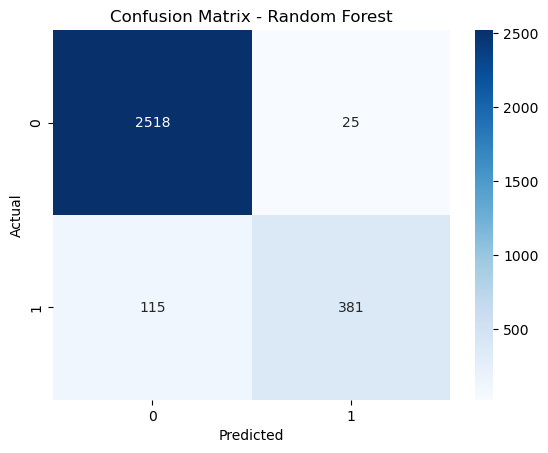

In [183]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 9. Feature Importance

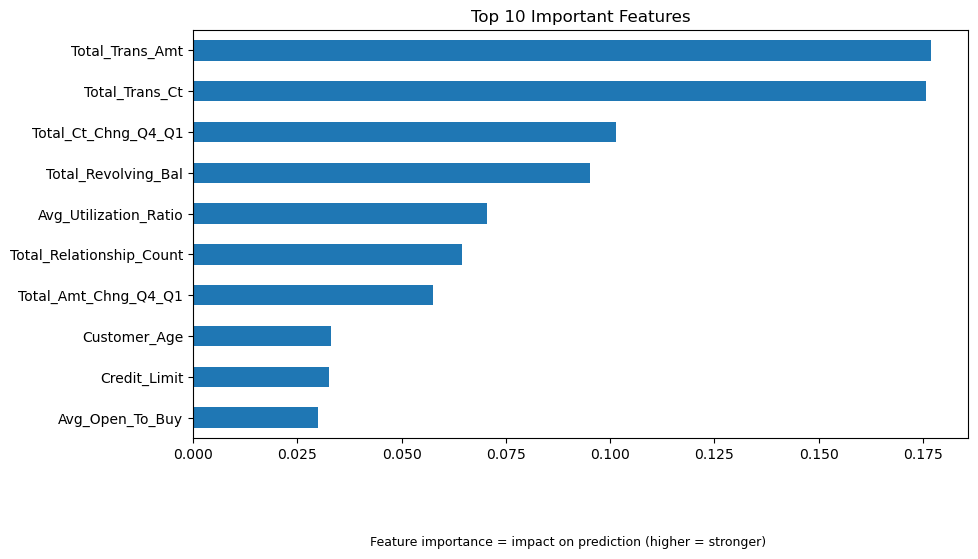

In [184]:
importances = rf.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

# Keep only top 10
top10 = feat_importance.head(10)

plt.figure(figsize=(10,6))

# Horizontal bar chart
top10.sort_values().plot(kind='barh')

plt.title("Top 10 Important Features")

# Add space at bottom
plt.subplots_adjust(bottom=0.2)

# Add note below chart
plt.figtext(0.5, 0.02,
"Feature importance = impact on prediction (higher = stronger)",
ha="center", fontsize=9)

plt.savefig("Top_10_Important_Features.png", bbox_inches='tight')

plt.show()

## 10. Conclusion

Based on the data analysis, the dataset appears to be clean and of good quality. The two Naive Bayes classifier columns were removed because they are not actual predictive features and could introduce data leakage. The dataset does not contain any missing values, which simplifies the preprocessing step.

From the churn distribution, the dataset is imbalanced, with approximately 8,500 existing customers and around 1,500 customers who have churned. This indicates that most customers remain with the bank, while a smaller portion leave.

Looking at the Age vs Churn analysis, both groups have a very similar age distribution. The average age is around 46 years for both existing and churned customers. The presence of a few outliers does not significantly affect the overall distribution. This suggests that age is not a strong factor influencing customer churn.

Similarly, the Credit Limit vs Churn analysis shows that both groups have comparable distributions, with many outliers present in both categories. The median values are also very close. This indicates that credit limit alone is not a decisive factor in whether a customer stays or leaves.

However, the Total Transaction Amount shows a clear difference between the two groups. Customers who churn tend to have significantly lower transaction amounts compared to those who remain. This suggests that lower engagement with the credit card may be a strong indicator of potential churn. Customers with lower spending activity are more likely to leave, which can be useful for identifying at-risk customers.

The Gender vs Churn analysis shows no significant difference between male and female customers. Both groups display a similar distribution of existing and churned customers, suggesting that gender does not play a major role in predicting customer churn.

From the modeling results, Logistic Regression achieved an accuracy of approximately 85.9%, while Random Forest performed significantly better with an accuracy of about 96.0% and a ROC-AUC score of 0.988. This indicates that the Random Forest model is highly effective in distinguishing between churned and existing customers.

The confusion matrix shows that the model correctly classified the majority of customers, with a relatively small number of misclassifications. This further confirms that the model performs well.

Finally, the feature importance analysis shows that Total Transaction Amount, Total Transaction Count, and Total Count Change are among the most important factors in predicting churn. These features are directly related to customer activity and engagement, which supports the earlier findings from the EDA.

Overall, the results suggest that customer behavior and transaction activity are key drivers of churn, while demographic features such as age and gender have less impact.